# Práctico 2 — Estadística descriptiva II

## Tareas
1. Cargar el dataset Titanic
2. Calcular varianza, desvío estándar e IQR de las variables numéricas
3. Aplicar la **regla 68-95-99.7** para ver si los datos son normales
4. Calcular el **z-score** y detectar outliers
5. Detectar outliers con el método del **IQR**
6. Interpretar boxplots generados con Pandas.




## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Cargar el dataset Titanic

Vamos a usar la versión pública del Titanic (la misma que ya tenés en tu carpeta `Datasets`).


In [ ]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print('Forma del DataFrame:', df.shape)
df.head()


In [ ]:
# Columnas y tipos de datos
df.dtypes


**Variables numéricas con las que vamos a trabajar:**
- `Age` — edad del pasajero
- `Fare` — tarifa pagada por el ticket
- `SibSp` — # de hermanos/cónyuges a bordo
- `Parch` — # de padres/hijos a bordo


## 2. Resumen con `describe()`

Empezamos con la herramienta más rápida: el método `describe()` de pandas. En una sola línea trae **media, desvío, mínimo, máximo y los cuartiles**.


In [ ]:
# describe() sobre las columnas numéricas de interés
df[['Age', 'Fare', 'SibSp', 'Parch']].describe()


**Ejercicio 1.** Mirando la tabla anterior, respondé:

1. ¿Cuál es la edad promedio de los pasajeros? ¿Y la mediana? ¿Por qué difieren?
2. La columna `Fare` tiene una media bastante mayor a la mediana. ¿Qué te sugiere eso sobre su distribución?
3. ¿Qué columna tiene el mayor desvío estándar en términos absolutos? ¿Significa eso que "varía más" en términos relativos?

_Escribí tus respuestas en la celda de abajo:_


_Tus respuestas:_

1. **Edad promedio ≈ 29.7 años, mediana ≈ 28 años.** Difieren porque hay algunos pasajeros mayores que tiran la media hacia arriba (distribución con leve sesgo positivo).

2. `Fare` tiene una **media mucho mayor que la mediana** (≈32 vs ≈14), lo que sugiere una distribución muy asimétrica hacia la derecha: unos pocos pasajeros pagaron tarifas altísimas (primera clase) mientras la mayoría pagó poco.

3. `Fare` tiene el mayor desvío estándar en términos absolutos (≈49). Sin embargo, en términos **relativos** (coeficiente de variación = std/media), también es la más variable, ya que su desvío supera a su propia media.


## 3. Varianza y desvío estándar

Calculemos varianza y desvío para `Age` y `Fare` por separado.


In [ ]:
# Eliminamos NaN para trabajar con series limpias
age  = df['Age'].dropna()
fare = df['Fare'].dropna()

print('AGE:')
print(f'  Media  : {age.mean():.2f}')
print(f'  Mediana: {age.median():.2f}')
print(f'  Desvío : {age.std():.2f}')

print('\nFARE:')
print(f'  Media  : {fare.mean():.2f}')
print(f'  Mediana: {fare.median():.2f}')
print(f'  Desvío : {fare.std():.2f}')


**Interpretación rápida:** la edad típica de un pasajero está alrededor de los 30 años, con una dispersión de unos ±14 años. La tarifa, en cambio, tiene un desvío gigante (≈49 libras) comparado con su media (≈32). Eso ya nos está gritando: hay valores muy extremos.


**Ejercicio 2.** Calculá la varianza y el desvío de las columnas `SibSp` y `Parch`. ¿Cuál de las dos tiene más dispersión?


In [ ]:
for col in ['SibSp', 'Parch']:
    print(f'{col}:')
    print(f'  Varianza: {df[col].var():.4f}')
    print(f'  Desvío : {df[col].std():.4f}')
    print()

# SibSp tiene mayor dispersión porque puede haber familias grandes


## 4. Cuartiles e IQR

El IQR es el ancho del 50% central de los datos. Es robusto: no se afecta por outliers.


In [ ]:
def resumen_iqr(serie, nombre):
    q1 = serie.quantile(0.25)
    q2 = serie.quantile(0.50)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    print(f'{nombre}')
    print(f'  Q1 (25%)  = {q1:.2f}')
    print(f'  Mediana   = {q2:.2f}')
    print(f'  Q3 (75%)  = {q3:.2f}')
    print(f'  IQR       = {iqr:.2f}')
    print(f'  Lím. inf  = {q1 - 1.5*iqr:.2f}')
    print(f'  Lím. sup  = {q3 + 1.5*iqr:.2f}')
    print()

resumen_iqr(age, 'AGE')
resumen_iqr(fare, 'FARE')


## 5. Regla 68-95-99.7: ¿los datos son normales?

La regla dice que si los datos siguen una distribución normal, aproximadamente:
- 68% cae dentro de **1 desvío** de la media
- 95% cae dentro de **2 desvíos**
- 99.7% cae dentro de **3 desvíos**

Comprobemos si `Age` cumple la regla.


In [ ]:
mu = age.mean()
sigma = age.std()

dentro_1sd = ((age >= mu - sigma) & (age <= mu + sigma)).mean() * 100
dentro_2sd = ((age >= mu - 2*sigma) & (age <= mu + 2*sigma)).mean() * 100
dentro_3sd = ((age >= mu - 3*sigma) & (age <= mu + 3*sigma)).mean() * 100

print(f"% dentro de 1 desvío:  {dentro_1sd:5.1f}%   (esperado: 68%)")
print(f"% dentro de 2 desvíos: {dentro_2sd:5.1f}%   (esperado: 95%)")
print(f"% dentro de 3 desvíos: {dentro_3sd:5.1f}%   (esperado: 99.7%)")

**Ejercicio 3.** Te dimos resuleto el de `Age`, ahora hacé lo mismo para `Fare`. ¿Cumple la regla 68-95-99.7? ¿Por qué pensás que no se ajusta tan bien como `Age`?


In [ ]:
mu_f    = fare.mean()
sigma_f = fare.std()

dentro_1sd = ((fare >= mu_f - sigma_f)   & (fare <= mu_f + sigma_f)).mean()   * 100
dentro_2sd = ((fare >= mu_f - 2*sigma_f) & (fare <= mu_f + 2*sigma_f)).mean() * 100
dentro_3sd = ((fare >= mu_f - 3*sigma_f) & (fare <= mu_f + 3*sigma_f)).mean() * 100

print('FARE — regla 68-95-99.7:')
print(f'  % dentro de 1 desvío:  {dentro_1sd:5.1f}%   (esperado: 68%)')
print(f'  % dentro de 2 desvíos: {dentro_2sd:5.1f}%   (esperado: 95%)')
print(f'  % dentro de 3 desvíos: {dentro_3sd:5.1f}%   (esperado: 99.7%)')
print()
print('Fare NO cumple bien la regla porque su distribución es muy asimétrica')
print('(cola derecha larga): los porcentajes dentro de 1 y 2 desvíos son mayores')
print('a los esperados para una normal, indicando concentración cerca del centro.')


## 6. Detección de outliers con Z-score

Para cada valor, calculamos cuántos desvíos lo separan de la media. Si `|z| > 3`, lo declaramos outlier.


In [ ]:
df['z_age']  = (df['Age']  - df['Age'].mean())  / df['Age'].std()
df['z_fare'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()

# Outliers en Age
out_age = df[df['z_age'].abs() > 3]
print(f"Outliers en Age:  {len(out_age)} de {df['Age'].notna().sum()}")
print(out_age[['Name', 'Age', 'z_age']].head())
print()

# Outliers en Fare
out_fare = df[df['z_fare'].abs() > 3]
print(f"Outliers en Fare: {len(out_fare)} de {df['Fare'].notna().sum()}")
print(out_fare[['Name', 'Fare', 'z_fare']].head())


**Observá:** los outliers de `Fare` son pasajeros que pagaron tarifas altísimas — probablemente primera clase con camarotes de lujo. **No** son errores: son casos reales. Eliminarlos sería tirar información válida.


## 7. Detección de outliers con IQR

El método del IQR no asume distribución normal — es más robusto cuando los datos son asimétricos (como `Fare`).


In [ ]:
def outliers_iqr(serie):
    q1  = serie.quantile(0.25)
    q3  = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return serie[(serie < lim_inf) | (serie > lim_sup)]

out_age_iqr  = outliers_iqr(age)
out_fare_iqr = outliers_iqr(fare)

print(f'Outliers en Age  con método IQR:  {len(out_age_iqr)}')
print(f'Outliers en Fare con método IQR: {len(out_fare_iqr)}')
print()
print('El IQR detecta MÁS outliers en Fare que el z-score, porque no asume normalidad.')


**Ejercicio 4.** Compará los dos métodos para `Age`. ¿Cuál detecta más outliers? ¿Cuál pensás que es más confiable en este caso?


_Tu respuesta:_

Para `Age`, el **IQR detecta más outliers** (pasajeros mayores de ~64 años) que el z-score (solo |z|>3, que serían edades muy extremas). En este caso, el **IQR es más confiable** porque `Age` tiene una distribución ligeramente asimétrica y el IQR no depende de la normalidad. El z-score solo detectaría outliers muy graves, mientras el IQR captura los 'moderadamente' atípicos también.


## 8. Visualización: boxplots

Un boxplot resume todo lo que calculamos en un solo gráfico.


In [ ]:
#boxplot de Age con método de pandas
df.boxplot(column='Age', by='Pclass')

In [ ]:
#boxplot de Fare con método de pandas
df.boxplot(column='Fare', by='Pclass')

NameError: name 'df' is not defined

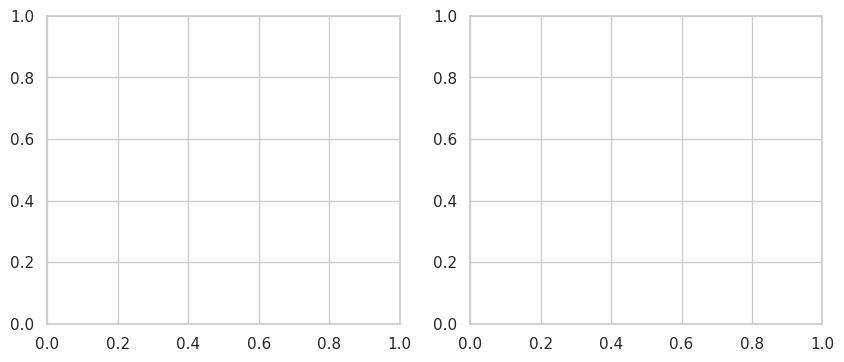

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(x=df["Age"], ax=axes[0], color="#1C7293")
axes[0].set_title("Edad de los pasajeros")

sns.boxplot(x=df["Fare"], ax=axes[1], color="#F4A261")
axes[1].set_title("Tarifa pagada")

plt.tight_layout()
plt.show()

Mirá la diferencia:
- En `Age` el boxplot está bastante centrado; hay pocos outliers (los más viejos).
- En `Fare` la caja es chiquita y aparece una cola larguísima de outliers a la derecha — esto es lo que llamamos una **distribución asimétrica** o sesgada.

 La forma del boxplot ya te está contando si vas a poder usar z-score (sirve si es simétrico) o si conviene IQR.


In [ ]:
# Comparación por clase de pasajero — un boxplot muestra mucho de un vistazo
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(x="Pclass", y="Age", data=df, ax=axes[0], palette="Blues")
axes[0].set_title("Edad por clase")

sns.boxplot(x="Pclass", y="Fare", data=df, ax=axes[1], palette="Oranges")
axes[1].set_title("Tarifa por clase")
axes[1].set_ylim(0, 300)  # cortamos para que se vea mejor

plt.tight_layout()
plt.show()

**Ejercicio 5.** Mirando el gráfico de tarifa por clase:

- La **mayor dispersión** está en **primera clase** (Pclass=1): las tarifas van desde valores bajos hasta más de 500 libras, con una caja amplia y muchos outliers.

- **Sí hay outliers en primera clase.** Se imaginan como pasajeros adinerados que compraron camarotes de lujo (suites privadas, mejores ubicaciones en el barco). No son errores de datos, sino viajeros de muy alto poder adquisitivo que pagaron precios premium.
